In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

In [2]:
images = Path('datasets')
outputs = Path('outputs/sift/')
sfm_pairs = outputs / 'pairs-sfm.txt'
# loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

# feature_conf = extract_features.confs['disk']
# matcher_conf = match_features.confs['disk+lightglue']
# matcher_conf = match_features.confs['superglue']

feature_conf = extract_features.confs['sift']
matcher_conf = match_features.confs['NN-ratio']


3 mapping images


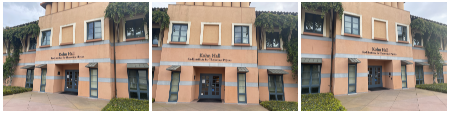

In [3]:
references = [str(p.relative_to(images)) for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [4]:
# extract_features.main(feature_conf, images, image_list=references, feature_path=features)
# pairs_from_exhaustive.main(sfm_pairs, image_list=references)
# match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches)

In [5]:
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def load_image(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_features(features_h5, key):
    with h5py.File(features_h5, 'r') as f_feat:
        kpts = [None] * len(key)
        for i,k in enumerate(key):
            if k in f_feat:
                kpts[i] = f_feat[k]['keypoints'][:]
            else:
                raise KeyError(f"Key '{k}' not found in {features_h5}")
    return kpts

def load_matches(matches_h5, key1, key2):
    with h5py.File(matches_h5, 'r') as f_match:
        if key1 in f_match and key2 in f_match[key1]:
            matches = f_match[key1][key2]['matches0'][:]
        elif key2 in f_match and key1 in f_match[key2]:
            matches = f_match[key2][key1]['matches0'][:]
        else:
            raise KeyError(f"No matches found for '{key1}' and '{key2}'")
    return matches


def visualize_keypoints(image_path, h5_file, key):
    img = load_image(image_path)
    keypoints = load_features(h5_file, [key])[0]
    for (x, y) in keypoints:
        cv2.circle(img, (int(x), int(y)), 10, (0, 255, 0), -1)
    plt.figure(figsize=(8, 6))
    plt.title(f"Keypoints: {key}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()


def visualize_matches(image_path1, image_path2, key1, key2, features_h5, matches_h5):
    img1 = load_image(image_path1)
    img2 = load_image(image_path2)

    kpts1, kpts2 = load_features(features_h5, [key1, key2])

    matches = load_matches(matches_h5, key1, key2)

    valid = matches > -1
    matched_kpts1 = kpts1[valid]
    matched_kpts2 = kpts2[matches[valid]]

    # Combine two images side by side
    height = max(img1.shape[0], img2.shape[0])
    combo = np.zeros((height, img1.shape[1] + img2.shape[1], 3), dtype=np.uint8)
    combo[:img1.shape[0], :img1.shape[1]] = img1
    combo[:img2.shape[0], img1.shape[1]:] = img2

    for pt1, pt2 in zip(matched_kpts1, matched_kpts2):
        pt1 = tuple(np.round(pt1).astype(int))
        pt2 = tuple(np.round(pt2).astype(int) + np.array([img1.shape[1], 0]))
        cv2.line(combo, pt1, pt2, (255, 0, 0), 3)

    plt.figure(figsize=(12, 6))
    plt.title(f"Matches: {key1} ↔ {key2} ({len(matched_kpts1)} matches)")
    plt.imshow(combo)
    plt.axis('off')
    plt.show()


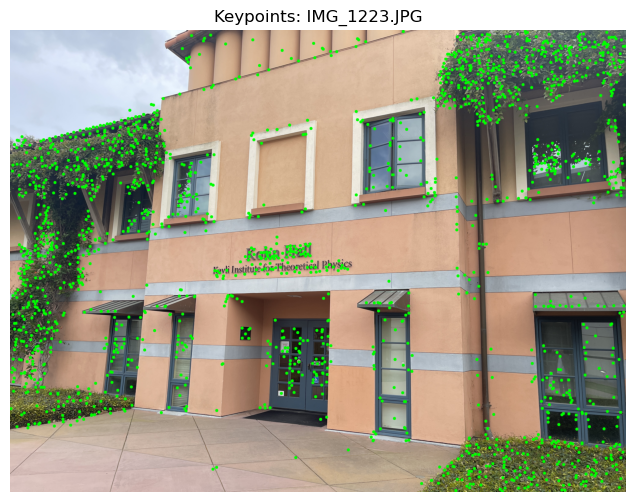

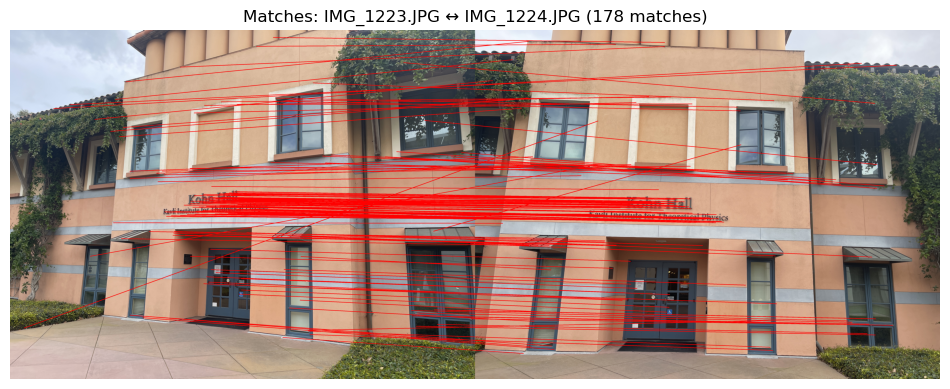

In [6]:
images_dir = Path("datasets")
features_path = str(features)
matches_path = str(matches)

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"

img1_path = images_dir / key1
img2_path = images_dir / key2

# 可视化关键点
visualize_keypoints(img1_path, features_path, key1)

# 可视化匹配点
visualize_matches(img1_path, img2_path, key1, key2, features_path, matches_path)


In [7]:
%load_ext autoreload
%autoreload 2

# import import_ipynb
import cv2
import m1

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"
key3 = "IMG_1226.JPG"
features_path = "outputs/sift/features.h5"
matches_path = "outputs/sift/matches.h5"

img_1 = cv2.imread("datasets\IMG_1223.JPG")
img_2 = cv2.imread("datasets\IMG_1224.JPG")
img_3 = cv2.imread("datasets\IMG_1226.JPG")

kpts1, kpts2, kpts3 = load_features(features_path, [key1, key2, key3])
matches12 = load_matches(matches_path, key1, key2)
matches23 = load_matches(matches_path, key2, key3)
matches13 = load_matches(matches_path, key1, key3)

valid = matches12 > -1
matched12_kpts1 = kpts1[valid]
matched12_kpts2 = kpts2[matches12[valid]]

valid = matches23 > -1
matched23_kpts2 = kpts2[valid]
matched23_kpts3 = kpts3[matches23[valid]]

valid = matches13 > -1
matched13_kpts1 = kpts1[valid]
matched13_kpts3 = kpts3[matches13[valid]]

H_12 = m1.compute_homography_dlt_normalized(matched12_kpts1, matched12_kpts2)
H_23 = m1.compute_homography_dlt_normalized(matched23_kpts2, matched23_kpts3)
H_13 = m1.compute_homography_dlt_normalized(matched13_kpts1, matched13_kpts3)
print("H_12:\n", H_12)
print("H_23:\n", H_23)
print("H_13:\n", H_13)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
H_12:
 [[ 2.21923204e+00 -4.37676490e-02 -1.62223803e+03]
 [ 5.04252163e-01  1.55617034e+00 -1.07980985e+03]
 [ 2.32044856e-04 -1.82826215e-05  1.00000000e+00]]
H_23:
 [[ 2.68998374e+00 -1.20011710e-01 -2.14896678e+02]
 [ 8.75111023e-01  1.48784945e+00 -1.25090735e+03]
 [ 5.76086671e-04 -9.28862790e-05  1.00000000e+00]]
H_13:
 [[-3.25060941e+00 -7.39075445e-01  4.32457137e+03]
 [-1.49125976e+00 -1.64330226e+00  3.51677827e+03]
 [-9.44156543e-04 -3.17027428e-04  1.00000000e+00]]


d:\study\US\ucsb\courses\ECE281B\Computer-Vision\milestone2\m1.py:153: RuntimeWarning: overflow encountered in square
  dist_squared = np.sum(shifted**2, axis=1)
d:\Downloadssoftware\Anaconda3\envs\cv\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [8]:
F_12 = m1.compute_fundamental_matrix_normalized(matched12_kpts1, matched12_kpts2)
F_23 = m1.compute_fundamental_matrix_normalized(matched23_kpts2, matched23_kpts3)
F_13 = m1.compute_fundamental_matrix_normalized(matched13_kpts1, matched13_kpts3)

print("F_12:\n", F_12)
print("F_23:\n", F_23)
print("F_13:\n", F_13)

F_12:
 [[-2.33359299e-07 -2.51131555e-06  4.11555894e-03]
 [ 2.88784048e-06 -2.57963024e-08 -5.23678043e-03]
 [-4.00134017e-03  4.29418108e-03  1.00000000e+00]]
F_23:
 [[ 2.28803963e-08  6.78824538e-07 -1.10024962e-03]
 [-5.89741139e-07 -4.54548970e-08  1.10847121e-03]
 [ 7.71437243e-04 -1.50951599e-03  1.00000000e+00]]
F_13:
 [[ 1.22135714e-07  1.04863108e-06 -1.88205053e-03]
 [-1.11495126e-06 -9.09392315e-08  1.95510007e-03]
 [ 1.39151276e-03 -2.02879145e-03  1.00000000e+00]]


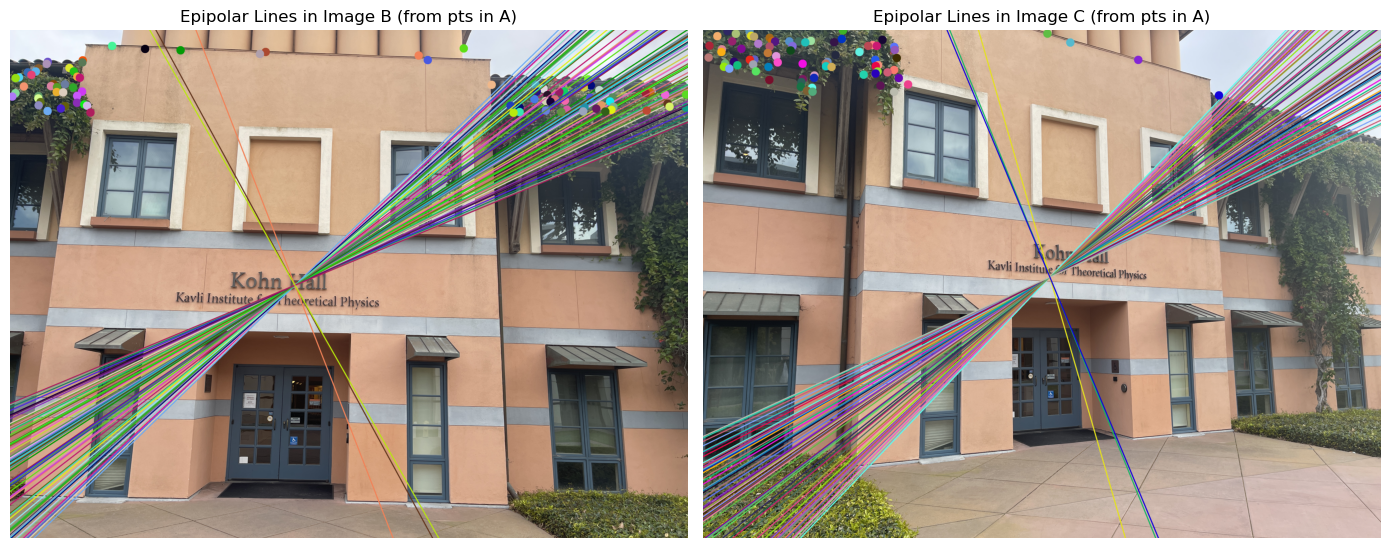

In [9]:
m1.draw_epipolar_lines(img_1, img_2, img_3, kpts1[:100], kpts2[:100], kpts3[:100], F_12, F_13)

In [19]:
from build_database import build_database

build_database(
    features_h5_path="outputs/SuperPoints/features.h5",
    matches_h5_path="outputs/SuperPoints/matches.h5",
    output_db_path="outputs/SuperPoints/database.db"
)


Processing matches: 100%|██████████| 11/11 [00:00<00:00, 161.34it/s]

Saved pruned matches to outputs\SuperPoints\database.db


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_homography_projection(img1, img2, pts1, pts2):
    """
    Estimate H using RANSAC, warp pts1 using H and draw them on img2 with pts2.
    """
    # Step 1: Estimate H with RANSAC
    H, mask = cv2.findHomography(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    print("Estimated Homography:\n", H)
    inliers1 = pts1[mask.ravel() == 1]
    inliers2 = pts2[mask.ravel() == 1]

    # Step 2: Project pts1 into img2 using H
    pts1_homo = np.hstack([inliers1, np.ones((inliers1.shape[0], 1))])  # Nx3
    projected_pts = (H @ pts1_homo.T).T  # Nx3
    projected_pts /= projected_pts[:, 2:]  # Normalize
    projected_pts = projected_pts[:, :2]

    # Step 3: Draw projected points vs ground truth points on img2
    img2_vis = img2.copy()
    for pt_proj, pt_gt in zip(projected_pts, inliers2):
        # projected: red cross
        cv2.drawMarker(img2_vis, tuple(np.round(pt_proj).astype(int)), (255, 0, 0), markerType=cv2.MARKER_TILTED_CROSS, thickness=10)
        # ground truth: green dot
        cv2.circle(img2_vis, tuple(np.round(pt_gt).astype(int)), radius=10, color=(0, 255, 0), thickness=-1)

    # Step 4: Show
    plt.figure(figsize=(10, 8))
    plt.title("Mapped points (red) vs Ground truth (green) on target image")
    plt.imshow(cv2.cvtColor(img2_vis, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


Estimated Homography:
 [[ 2.37200148e+00 -7.92260678e-03 -1.80775941e+03]
 [ 5.64546461e-01  1.67648213e+00 -1.23653750e+03]
 [ 2.64427125e-04 -2.76210495e-07  1.00000000e+00]]


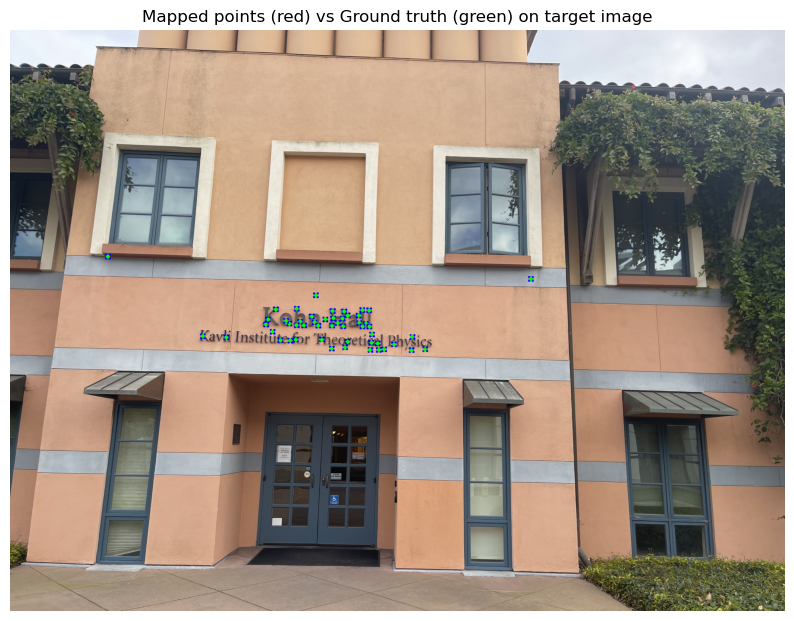

In [29]:
draw_homography_projection(img_1, img_2, matched12_kpts1, matched12_kpts2)
